# 05 Did rich countries offshore their emissions?

Every result so far has used **production-based** emissions: the CO2 released inside a country's borders. That's how countries report emissions under the UN climate framework, and it's what national targets are measured against.

But there's an obvious catch. If the UK stops making steel and imports it from China instead, UK emissions fall and Chinese emissions rise, even though British people use just as much steel. Notebook 04 flagged exactly this: much of the fall in energy intensity could be heavy industry moving abroad rather than genuine efficiency.

**Consumption-based** emissions fix this by following the goods. They take a country's production emissions, add the emissions embedded in everything it imports, and subtract the emissions embedded in everything it exports:

**consumption = production + imported emissions - exported emissions**

The difference (`trade_co2` in the data) is a country's net imported carbon. A positive value means it consumes more carbon than it produces.

**The question:** do the decoupling successes from notebook 03 survive when we count emissions this way?

In [1]:
# --- Setup ---
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.config import DATA_PROCESSED, FIGURES, TABLES, START_YEAR, END_YEAR, AVG_WINDOW
from src.sample import endpoint_means, classify_decoupling
from src.plotting import set_style, DECOUPLING_ORDER, BLUE, ORANGE, GREY, INK_SOFT

set_style()
pd.set_option("display.width", 120)

# Colours for this notebook: production vs consumption
PROD, CONS = BLUE, ORANGE

sample = pd.read_parquet(DATA_PROCESSED / "analysis_panel.parquet")

# Only countries with consumption-based emissions for every year
has_cons = sample.groupby("country")["consumption_co2"].apply(lambda s: s.notna().all())
trade = sample[sample["country"].isin(has_cons[has_cons].index)].copy()

latest = sample[sample["year"] == END_YEAR]
covered = latest[latest["country"].isin(trade["country"])]["co2"].sum() / latest["co2"].sum() * 100
print(f"Countries with consumption-based emissions: {trade['country'].nunique()} of {sample['country'].nunique()}")
print(f"They produce {covered:.0f}% of the sample's emissions")

Countries with consumption-based emissions: 109 of 143
They produce 97% of the sample's emissions


109 countries have consumption-based emissions for the whole period, covering almost all of the sample's emissions. All comparisons in this notebook use these 109, so production and consumption results are like for like.

One thing to be upfront about: consumption-based emissions are **modelled**, not measured. They come from global input-output models that trace supply chains between countries, and the estimates carry more uncertainty than production figures, especially for the early 1990s. The broad patterns are well established in the research, but small differences for individual countries shouldn't be over-read.

## 1. Who imports carbon, and who exports it?

Net traded emissions, averaged over 2020 to 2022. Positive means a country consumes more carbon than it produces.

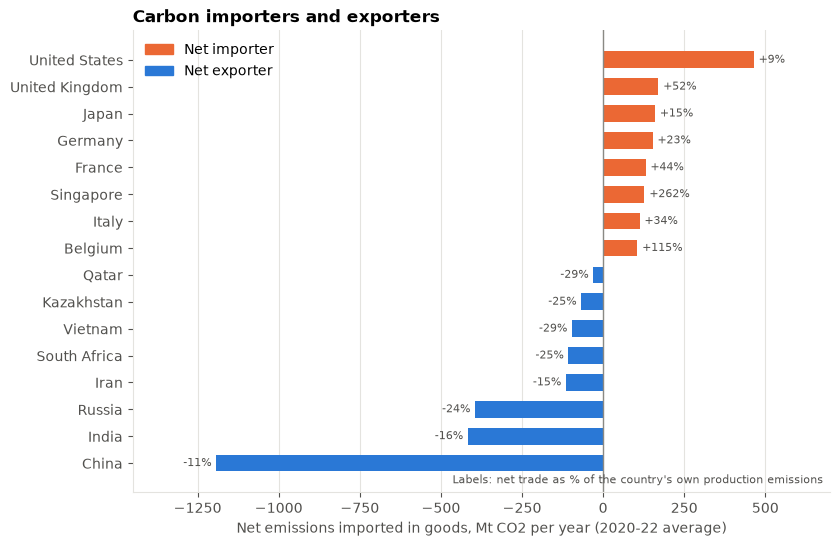

,trade_co2_end,trade_share_end
country,,
United States,464.0,9.0
United Kingdom,170.0,52.0
Japan,160.0,15.0
Germany,152.0,23.0
France,131.0,44.0
Singapore,128.0,262.0
Italy,112.0,34.0
Belgium,105.0,115.0
Qatar,-31.0,-29.0


In [2]:
ends = endpoint_means(trade, ["gdp", "population", "co2", "consumption_co2", "trade_co2"])
ends["trade_share_end"] = ends["trade_co2_end"] / ends["co2_end"] * 100

importers = ends.nlargest(8, "trade_co2_end")
exporters = ends.nsmallest(8, "trade_co2_end")
both = pd.concat([exporters, importers.iloc[::-1]]).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
colours = np.where(both["trade_co2_end"] > 0, CONS, PROD)
ax.barh(both.index, both["trade_co2_end"], color=colours, height=0.62)
for y, (v, s) in enumerate(zip(both["trade_co2_end"], both["trade_share_end"])):
    ax.text(v + (15 if v > 0 else -15), y, f"{s:+.0f}%", va="center", ha="left" if v > 0 else "right",
            fontsize=8, color=INK_SOFT)
ax.axvline(0, color=GREY, linewidth=1)
ax.invert_yaxis()
ax.set_xlim(-1450, 700)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Net emissions imported in goods, Mt CO2 per year (2020-22 average)")
ax.set_title("Carbon importers and exporters")
ax.text(0.99, 0.02, "Labels: net trade as % of the country's own production emissions",
        transform=ax.transAxes, ha="right", fontsize=8, color=INK_SOFT)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CONS, label="Net importer"), Patch(color=PROD, label="Net exporter")],
          loc="upper left")
fig.savefig(FIGURES / "05_carbon_importers_exporters.png")
plt.show()

both[["trade_co2_end", "trade_share_end"]].round(0)

The split is clear. The big **net importers** are rich consumer economies: the US, the UK, Japan, Germany and France. The big **net exporters** are manufacturing and resource economies: China, India, Russia, South Africa and Vietnam.

In tonnes, the US imports the most. As a share of its own emissions, the UK stands out: it consumes about 52% more CO2 than it produces. China exports about 1.2 billion tonnes a year embedded in goods, roughly 11% of its production.

(Singapore and Belgium also have very high import shares, but they are trade and shipping hubs where a lot of goods pass through, so their figures are less meaningful as a lifestyle footprint.)

## 2. Production vs consumption for key countries

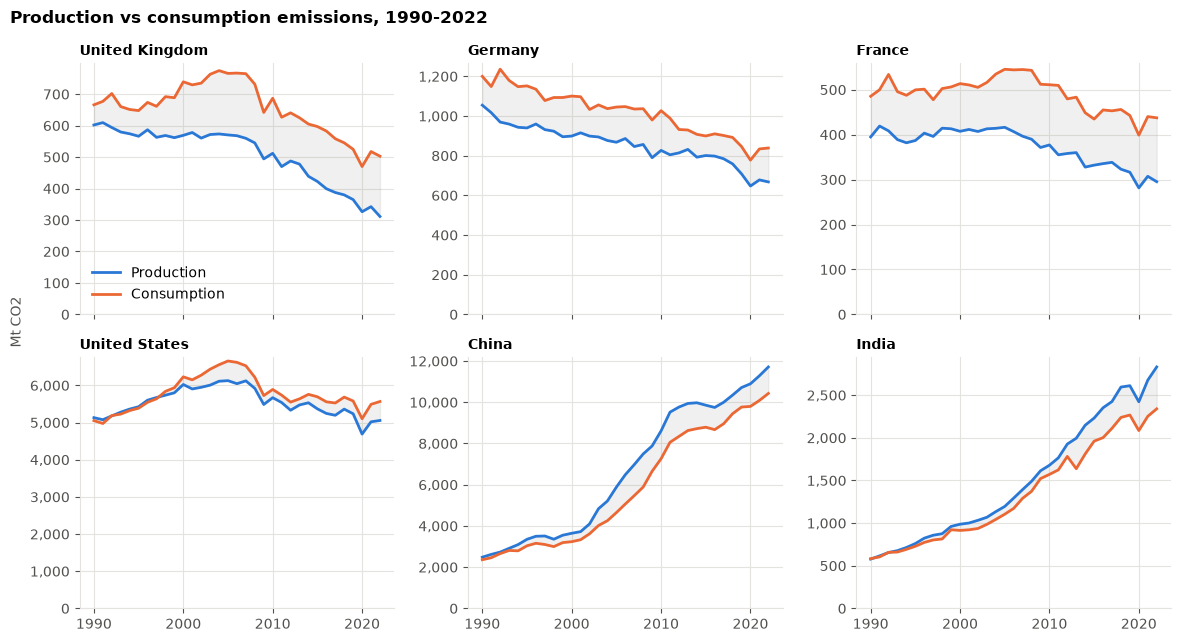

In [3]:
countries = ["United Kingdom", "Germany", "France", "United States", "China", "India"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharex=True)
for ax, name in zip(axes.flat, countries):
    d = trade[trade["country"] == name].set_index("year")
    ax.plot(d.index, d["co2"], color=PROD, label="Production")
    ax.plot(d.index, d["consumption_co2"], color=CONS, label="Consumption")
    ax.fill_between(d.index, d["co2"], d["consumption_co2"], color=GREY, alpha=0.12)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, None)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.supylabel("Mt CO2", color=INK_SOFT, fontsize=10)
fig.suptitle("Production vs consumption emissions, 1990-2022", x=0.02, ha="left", fontweight="bold", fontsize=12)
axes[0, 0].legend(loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES / "05_production_vs_consumption.png")
plt.show()

For the UK, Germany and France, the consumption line (orange) sits above production (blue) for the whole period: they have always imported more carbon than they export. The US was roughly balanced in the early 1990s and became a clear net importer from the late 1990s. For China and India it's the other way round.

The shape of the gap tells a story too. China's net exported emissions nearly quadrupled in six years, from about 0.4 Gt in 2001 (the year it joined the World Trade Organization) to 1.5 Gt in 2007. That's the same period in which the gap for the rich countries widened fastest. The UK's gap peaked around 2007 and has narrowed a little since, but consumption emissions have still fallen more slowly than production.

## 3. Has offshoring grown over time?

Adding up the richest quarter of countries (by GDP per person) shows the overall trend in imported carbon.

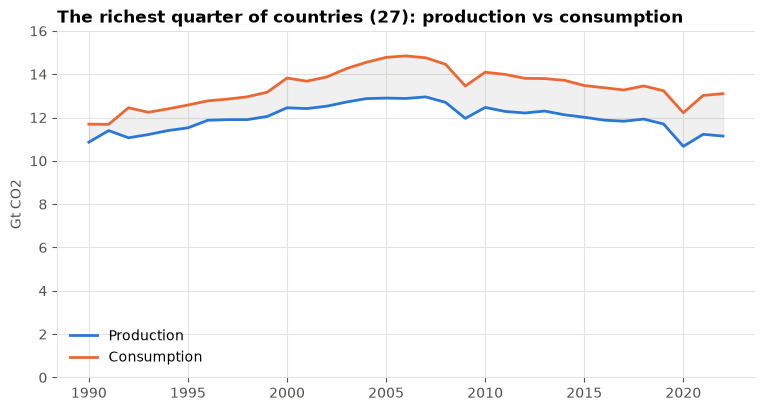

,co2,consumption_co2,trade_co2,imported_share
year,,,,
1990,10863.8,11693.5,829.7,7.6
2000,12449.2,13823.1,1373.8,11.0
2007,12952.0,14757.3,1805.3,13.9
2010,12465.4,14092.8,1627.4,13.1
2015,12013.0,13475.8,1462.8,12.2
2022,11143.5,13101.8,1958.3,17.6


In [4]:
gdp_pc = ends["gdp_end"] / ends["population_end"]
income_group = pd.qcut(gdp_pc, 4, labels=["Lowest", "Lower-middle", "Upper-middle", "Highest"])
trade["income_group"] = trade["country"].map(income_group)

rich = (trade[trade["income_group"] == "Highest"]
        .groupby("year")[["co2", "consumption_co2", "trade_co2"]].sum())
rich["imported_share"] = rich["trade_co2"] / rich["co2"] * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rich.index, rich["co2"] / 1000, color=PROD, label="Production")
ax.plot(rich.index, rich["consumption_co2"] / 1000, color=CONS, label="Consumption")
ax.fill_between(rich.index, rich["co2"] / 1000, rich["consumption_co2"] / 1000, color=GREY, alpha=0.12)
ax.set_ylim(0, 16)
ax.set_ylabel("Gt CO2")
ax.set_title(f"The richest quarter of countries ({(income_group == 'Highest').sum()}): production vs consumption")
ax.legend(loc="lower left")
fig.savefig(FIGURES / "05_rich_countries_gap.png")
plt.show()

rich.loc[[1990, 2000, 2007, 2010, 2015, 2022]].round(1)

Net imported emissions for the richest countries more than doubled between 1990 and the mid-2000s, from under 1 Gt to nearly 2 Gt a year. They eased after the 2008 financial crisis, when trade slowed, then climbed again, and by 2022 were back at their highest level, around 18% on top of what these countries produce at home.

So offshoring is real and substantial. The next question is whether it's big enough to cancel out the decoupling.

## 4. The key test: does decoupling survive?

Here I rerun the decoupling classification from notebook 03 twice for the same 109 countries: once with production emissions, once with consumption emissions.

In [5]:
production = classify_decoupling(ends["gdp_start"], ends["gdp_end"], ends["co2_start"], ends["co2_end"])
consumption = classify_decoupling(ends["gdp_start"], ends["gdp_end"],
                                  ends["consumption_co2_start"], ends["consumption_co2_end"])

compare = pd.crosstab(production, consumption, rownames=["Production-based"], colnames=["Consumption-based"])
compare.reindex(index=DECOUPLING_ORDER, columns=DECOUPLING_ORDER).fillna(0).astype(int)

Consumption-based,Absolute,Relative,None,GDP fell
Production-based,,,,
Absolute,25,7,0,0
Relative,1,46,8,0
None,0,3,17,0
GDP fell,0,0,0,2


In [6]:
results = pd.DataFrame({
    "production": production,
    "consumption": consumption,
    "production_change_%": (ends["co2_end"] / ends["co2_start"] - 1) * 100,
    "consumption_change_%": (ends["consumption_co2_end"] / ends["consumption_co2_start"] - 1) * 100,
})

prod_decouplers = results[results["production"] == "Absolute"]
survive = prod_decouplers[prod_decouplers["consumption"] == "Absolute"]
drop = prod_decouplers[prod_decouplers["consumption"] != "Absolute"]
join = results[(results["consumption"] == "Absolute") & (results["production"] != "Absolute")]

print(f"Absolute decouplers on production emissions:  {len(prod_decouplers)}")
print(f"  ...still absolute on consumption emissions: {len(survive)}")
print(f"  ...drop out:                                {len(drop)}  ({', '.join(sorted(drop.index))})")
print(f"Newly absolute on consumption emissions:      {len(join)}  ({', '.join(join.index)})")

Absolute decouplers on production emissions:  32
  ...still absolute on consumption emissions: 25
  ...drop out:                                7  (Azerbaijan, Belarus, Belgium, Croatia, Kuwait, Switzerland, United States)
Newly absolute on consumption emissions:      1  (Austria)


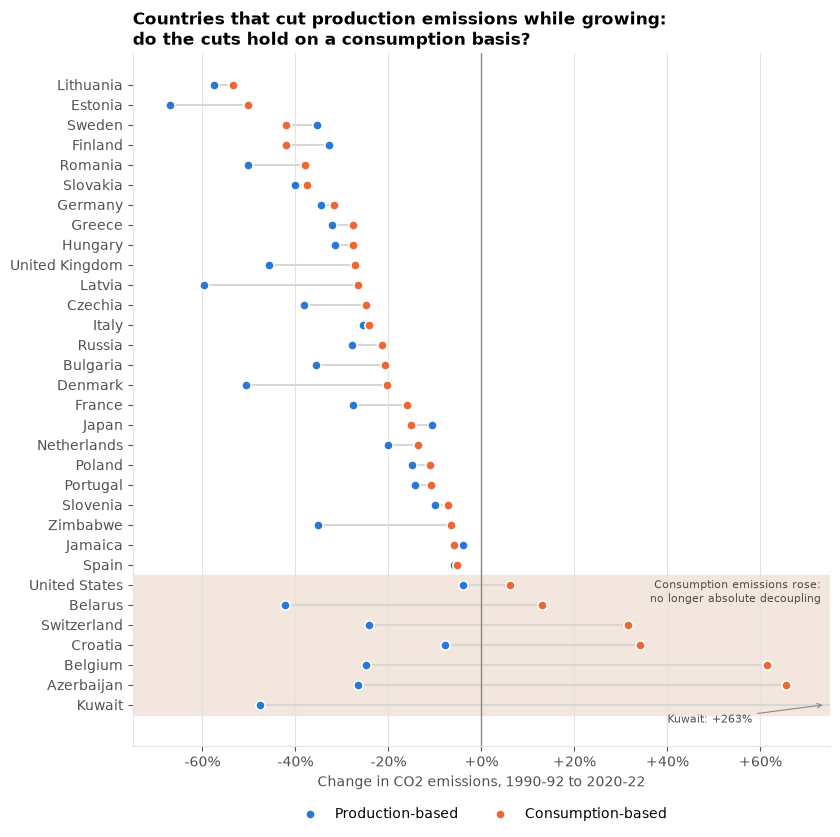

In [7]:
view = prod_decouplers.sort_values("consumption_change_%", ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(view))
ax.axvline(0, color=GREY, linewidth=1)
ax.hlines(y, view["production_change_%"], view["consumption_change_%"], color="#d8d7d2", linewidth=1.5, zorder=1)
ax.scatter(view["production_change_%"], y, color=PROD, s=45, zorder=3, label="Production-based",
           edgecolor="white", linewidth=1.2)
ax.scatter(view["consumption_change_%"], y, color=CONS, s=45, zorder=3, label="Consumption-based",
           edgecolor="white", linewidth=1.2)
ax.set_yticks(y, view.index)
ax.grid(axis="y", visible=False)
ax.set_xlim(-75, 75)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:+.0f}%"))

# Mark the countries whose consumption emissions actually rose
n_drop = (view["consumption_change_%"] >= 0).sum()
ax.axhspan(-0.5, n_drop - 0.5, color="#f3e6de", zorder=0)
ax.text(73, n_drop - 0.7, "Consumption emissions rose:\nno longer absolute decoupling",
        ha="right", va="top", fontsize=8, color=INK_SOFT)
ax.set_xlabel("Change in CO2 emissions, 1990-92 to 2020-22")
k = list(view.index).index("Kuwait")
ax.annotate(f"Kuwait: {view.loc['Kuwait', 'consumption_change_%']:+.0f}%", xy=(74, k), xytext=(40, k - 0.9),
            fontsize=8, color=INK_SOFT, arrowprops=dict(arrowstyle="->", color=GREY, linewidth=0.8))
ax.set_title("Countries that cut production emissions while growing:\ndo the cuts hold on a consumption basis?")
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.07))
fig.savefig(FIGURES / "05_decoupling_production_vs_consumption.png")
plt.show()

Kuwait's consumption emissions rose by over 250%, far off the chart. Its production-based "cut" was really the 1991 oil fires inflating its starting point, as noted in notebook 03.

### What this shows

**Most of the decoupling is real.** 25 of the 32 countries that cut production emissions while growing still cut emissions on a consumption basis. That includes the UK, Germany, France, Sweden, Japan and Denmark. Austria actually joins the group once trade is counted.

**But offshoring flattered almost everyone.** For most countries the orange dot sits to the right of the blue one, meaning their consumption emissions fell by less than their production emissions. The UK's cut shrinks from 46% to 27%, and Denmark's from 51% to 20%.

**Seven countries drop out completely**, and they fall into three groups:
- **Wealthy trading economies.** Switzerland and Belgium cut emissions at home, but their consumption emissions rose, by around a third and over 60%. Both import a large share of what they consume.
- **The United States**, the largest economy in the list. Its production emissions fell about 4%, but its consumption emissions rose about 6%. On a consumption basis, the US has only relatively decoupled.
- **Special cases** already flagged in earlier notebooks: Belarus and Azerbaijan (post-Soviet collapse), Croatia and Kuwait (war and the 1991 oil fires in the starting years).

## 5. How much of each cut was "given back" through trade?

For the countries that survived the test, one more measure: what fraction of their production-based cut still holds once imports are counted?

In [8]:
held = survive.assign(share_of_cut_held=survive["consumption_change_%"] / survive["production_change_%"] * 100)
held = held.sort_values("share_of_cut_held")
held[["production_change_%", "consumption_change_%", "share_of_cut_held"]].round(0)

,production_change_%,consumption_change_%,share_of_cut_held
country,,,
Zimbabwe,-35.0,-7.0,19.0
Denmark,-51.0,-20.0,40.0
Latvia,-60.0,-26.0,44.0
France,-28.0,-16.0,58.0
Bulgaria,-36.0,-21.0,58.0
United Kingdom,-46.0,-27.0,59.0
Czechia,-38.0,-25.0,65.0
Netherlands,-20.0,-14.0,68.0
Slovenia,-10.0,-7.0,73.0


The spread is wide. Some countries, including Sweden, Finland and Japan, cut their consumption emissions by *more* than their production emissions (over 100% held), so their progress isn't reliant on imports at all. Most others keep somewhere between half and all of their cut. The UK keeps a bit under 60%, and Denmark around 40%, so a meaningful share of their headline progress does rely on goods made elsewhere.

## Save the results

In [9]:
out = results.round(1)
out["income_group"] = income_group
out.to_csv(TABLES / "decoupling_production_vs_consumption.csv")
rich.round(1).to_csv(TABLES / "rich_countries_imported_emissions.csv")
print(f"Saved results for {len(out)} countries")

Saved results for 109 countries


## Summary

- **Rich countries are net importers of carbon; manufacturing economies are net exporters.** The UK consumes about 52% more CO2 than it produces; China exports about 1.2 Gt a year in goods.
- **Offshoring has grown.** The richest quarter of countries imported under 1 Gt of CO2 a year in 1990 and nearly 2 Gt by 2022.
- **Most decoupling survives it.** 25 of 32 production-based absolute decouplers still cut emissions on a consumption basis, including the UK, Germany, France, Sweden and Japan.
- **But trade flattered the headline numbers.** The UK's cut shrinks from 46% to 27%, and Denmark's from 51% to 20%.
- **The US, Switzerland and Belgium drop out.** Their consumption emissions rose even though production emissions fell.

**Bottom line for the project:** offshoring explains part of rich countries' progress, but not most of it. The decoupling found in notebooks 03 and 04 is mostly genuine, just smaller than production figures suggest.